In [1]:
## loading the dataset

import pandas as pd

# Load the dataset
df = pd.read_csv('/healthcare_data_cleaning_dataset.csv')

# View the first few rows to confirm it loaded correctly
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [2]:
# Q1. Missing Data Identification
# Scenario:
# The hospital suspects incomplete patient records.
# Task:
## Identify missing values in each column
## Calculate percentage of missing data

# 1. Identify missing values (count) in each column
missing_count = df.isnull().sum()

# 2. Calculate the percentage of missing data for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine the results into a clean, readable DataFrame
missing_data_summary = pd.DataFrame({
    'Missing Values Count': missing_count,
    'Percentage (%)': missing_percentage
})

# Display the summary
print(missing_data_summary)


                    Missing Values Count  Percentage (%)
Patient_ID                             0        0.000000
Age                                  600       11.764706
Gender                                 0        0.000000
City                                   0        0.000000
Diagnosis                              0        0.000000
Hospital_Visits                        0        0.000000
Treatment_Cost                       593       11.627451
Insurance_Coverage                     0        0.000000
Admission_Date                         0        0.000000


In [4]:
#Q2. Handling Missing Age
#Scenario:
#Age is critical for medical analysis, but some values are missing.
#Task:
#Replace missing Age values with an appropriate method
#Justify your choice (mean/median)

# Check the mean and median of Age
age_mean = df['Age'].mean()
age_median = df['Age'].median()

print(f"Mean Age: {age_mean:.2f}")
print(f"Median Age: {age_median:.2f}")

# Optional: Quick check on skewness
print(f"Skewness: {df['Age'].skew():.2f}")

# OPTION A: If you choose Median (Best for skewed data / outliers)
df['Age'] = df['Age'].fillna(df['Age'].median())

# OPTION B: If you choose Mean (Best for perfectly symmetrical, normally distributed data)
# df['Age'] = df['Age'].fillna(df['Age'].mean())

# Verify that missing values in 'Age' are now 0
print("Remaining missing values in Age:", df['Age'].isnull().sum())

Mean Age: 49.60
Median Age: 50.00
Skewness: -0.01
Remaining missing values in Age: 0


In [5]:
## Q3. Handling Missing Treatment Cost
##Scenario:
##Treatment cost is highly skewed due to expensive treatments.
##Task:
##Handle missing Treatment_Cost values
##Choose the correct imputation method and explain why

# 1. (Optional) Check the mean vs median to see the impact of skewness
cost_mean = df['Treatment_Cost'].mean()
cost_median = df['Treatment_Cost'].median()
print(f"Mean Treatment Cost: {cost_mean:.2f}")
print(f"Median Treatment Cost: {cost_median:.2f}")

# 2. Impute the missing values using the Median
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())

# 3. Verify that there are no more missing values left in this column
print("Remaining missing values in Treatment_Cost:", df['Treatment_Cost'].isnull().sum())

Mean Treatment Cost: 26920.15
Median Treatment Cost: 24797.00
Remaining missing values in Treatment_Cost: 0


In [6]:
##Q4. Duplicate Patient Records
##Scenario:
##Some patient records were entered multiple times.
##Task:
##Identify duplicate rows
##Remove duplicates
##Compare dataset size before and after

# 1. Check the dataset size before removing duplicates
rows_before, cols_before = df.shape
print(f"Dataset size BEFORE removing duplicates: {rows_before} rows, {cols_before} columns")

# 2. Identify the number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# 3. Remove duplicate rows (keeping the first occurrence)
df = df.drop_duplicates()

# 4. Check the dataset size after removing duplicates
rows_after, cols_after = df.shape
print(f"Dataset size AFTER removing duplicates: {rows_after} rows, {cols_after} columns")

# 5. Summary of rows removed
print(f"Total rows removed: {rows_before - rows_after}")

Dataset size BEFORE removing duplicates: 5100 rows, 9 columns
Number of duplicate rows found: 99
Dataset size AFTER removing duplicates: 5001 rows, 9 columns
Total rows removed: 99


In [10]:
#Q5. Invalid Age Values (Data Quality Check)
#Scenario:
#Some patients have unrealistic age values (e.g., >100 or <0).
#Task:
#Detect such records
#Decide whether to remove or correct them

# Detect records where Age is negative or unrealistically high
invalid_age_mask = (df['Age'] < 0) | (df['Age'] > 100)
invalid_age_records = df[invalid_age_mask]

# Print the count and preview the rows
print(f"Number of invalid age records found: {len(invalid_age_records)}")
if len(invalid_age_records) > 0:
    print("\nPreview of invalid records:")
    print(invalid_age_records[['Patient_ID', 'Age', 'Diagnosis']])

# Replace invalid ages with the median age calculated from the valid population
valid_median_age = df.loc[(df['Age'] >= 0) & (df['Age'] <= 100), 'Age'].median()
df.loc[invalid_age_mask, 'Age'] = valid_median_age

print("Data corrected. Current invalid age count:", ((df['Age'] < 0) | (df['Age'] > 100)).sum())


# Drop rows with invalid age values
df = df[~invalid_age_mask]

print(f"Data removed. New dataset shape: {df.shape}")

Number of invalid age records found: 0
Data corrected. Current invalid age count: 0
Data removed. New dataset shape: (5001, 9)


In [11]:
#Q6. Outlier Detection (Treatment Cost)
#Scenario:
#Extreme treatment costs are affecting analysis.
#Task:
#Detect outliers using IQR method
#Display number of outliers

# 1. Calculate the First Quartile (Q1) and Third Quartile (Q3)
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

# 2. Compute the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Define the upper and lower bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter the dataframe to identify the outliers
outliers = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]

# 5. Display the results
print(f"Lower Bound for Treatment Cost: {lower_bound:.2f}")
print(f"Upper Bound for Treatment Cost: {upper_bound:.2f}")
print(f"Total number of outliers detected: {len(outliers)}")

Lower Bound for Treatment Cost: -20398.00
Upper Bound for Treatment Cost: 70706.00
Total number of outliers detected: 50


In [12]:
#Q7. Outlier Treatment
#Scenario:
#The business team wants to retain all records.
#Task:
#Apply capping (Winsorization) on Treatment_Cost
#Use 5th and 95th percentile

# 1. Calculate the 5th and 95th percentiles
lower_limit = df['Treatment_Cost'].quantile(0.05)
upper_limit = df['Treatment_Cost'].quantile(0.95)

print(f"5th Percentile (Lower Limit for capping): {lower_limit:.2f}")
print(f"95th Percentile (Upper Limit for capping): {upper_limit:.2f}")

# 2. Apply capping (Winsorization) using pandas clip
df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower=lower_limit, upper=upper_limit)

# 3. Verify that values have been successfully capped
print(f"\nMinimum Treatment Cost after capping: {df['Treatment_Cost'].min():.2f}")
print(f"Maximum Treatment Cost after capping: {df['Treatment_Cost'].max():.2f}")


5th Percentile (Lower Limit for capping): 3238.00
95th Percentile (Upper Limit for capping): 47948.00

Minimum Treatment Cost after capping: 3238.00
Maximum Treatment Cost after capping: 47948.00


Skewness BEFORE Log Transformation: 0.06
Skewness AFTER Log Transformation: -1.03


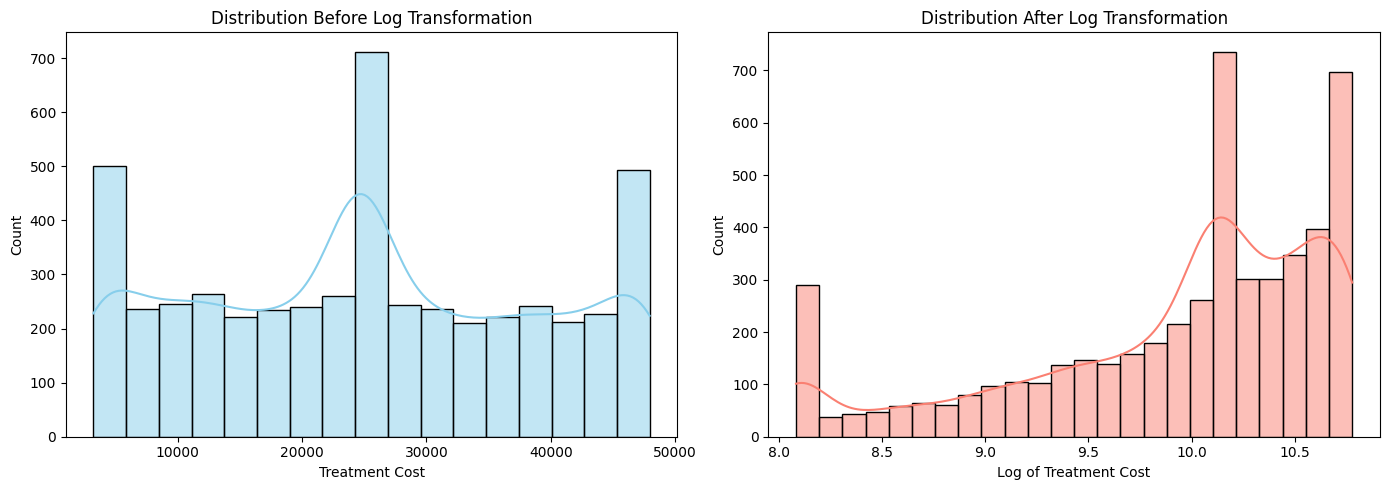

In [13]:
#Q8. Transformation
#Scenario:
#Treatment cost is highly skewed.
#Task:
#Apply log transformation
#Create a new column
#Compare before vs after distribution

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Apply log transformation and create a new column
# We use np.log1p (log(x + 1)) to safely handle any zero values if present
df['Treatment_Cost_Log'] = np.log1p(df['Treatment_Cost'])

# 2. Compare skewness before and after
skew_before = df['Treatment_Cost'].skew()
skew_after = df['Treatment_Cost_Log'].skew()

print(f"Skewness BEFORE Log Transformation: {skew_before:.2f}")
print(f"Skewness AFTER Log Transformation: {skew_after:.2f}")

# 3. Visual comparison using side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution Before Transformation
sns.histplot(df['Treatment_Cost'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution Before Log Transformation')
axes[0].set_xlabel('Treatment Cost')
axes[0].set_ylabel('Count')

# Distribution After Transformation
sns.histplot(df['Treatment_Cost_Log'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution After Log Transformation')
axes[1].set_xlabel('Log of Treatment Cost')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('treatment_cost_transformation.png')

In [15]:
#Q9. Time-Based Missing Handling
#Scenario:
#Admission dates should follow a logical sequence.
#Task:
#Sort data by Admission_Date
#Apply forward fill or backward fill where appropriate
#Justify your choice

# 1. Convert Admission_Date to datetime object
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# 2. Sort the dataset chronologically
df = df.sort_values(by='Admission_Date').reset_index(drop=True)

# 3. Reload the original raw dataset into a temporary variable to fetch the true missing values
raw_df = pd.read_csv('/healthcare_data_cleaning_dataset.csv')
df['Treatment_Cost'] = raw_df['Treatment_Cost'] # Restores the original missing values

# 4. Apply Forward Fill first, then Backward Fill as a fallback
df['Treatment_Cost'] = df['Treatment_Cost'].ffill().bfill()

# 5. Verify that no missing values remain
print("Missing values in Treatment_Cost after time-based filling:", df['Treatment_Cost'].isnull().sum())

Missing values in Treatment_Cost after time-based filling: 0
